In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_rel
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from tqdm.notebook import tqdm

In [2]:
adata = sc.read_h5ad('../data/simulation/TM_subset_cnt.h5ad')
celltype_cnts = adata.obs['cell_type'].value_counts()
celltype_cnts = celltype_cnts[celltype_cnts >= 50]

In [3]:
n_bins = 5

In [98]:
import os
import shutil

def get_setting_key(folder_name):
    parts = folder_name.split("__")
    parts = [p for p in parts if not p.startswith("seed-")]
    return "__".join(parts)

def merge_copy(sr_dir, base_dir, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    sr_keys = {}

    # ---- 1. copy all from _sr ----
    for d in os.listdir(sr_dir):
        src = os.path.join(sr_dir, d)
        if not os.path.isdir(src):
            continue

        key = get_setting_key(d)
        sr_keys[key] = True

        dst = os.path.join(out_dir, d)
        shutil.copytree(src, dst, dirs_exist_ok=True)

    # ---- 2. copy from base if not in sr ----
    for d in os.listdir(base_dir):
        src = os.path.join(base_dir, d)
        if not os.path.isdir(src):
            continue

        key = get_setting_key(d)

        if key in sr_keys:
            continue  # skip, already copied from sr

        dst = os.path.join(out_dir, d)
        shutil.copytree(src, dst, dirs_exist_ok=True)

# usage
merge_copy(
    "../results/icepop_casual_mc-75_min_purity-0_2_sr",
    "../results/icepop_casual_mc-75_min_purity-0_2",
    "../results/icepop_casual_mc-75_min_purity-0_2__merged_output"
)

In [101]:
merge_copy(
    "../data/simulation/causal_simulation_sr",
    "../data/simulation/causal_simulation",
    "../data/simulation/causal_simulation__merged_output"
)

In [106]:
import os
import shutil

# =============================
# PATHS
# =============================
dir_sr = "../results/seismic_casual_sr"
dir_base = "../results/seismic_casual"
out_dir = "../results/seismic_merged"

os.makedirs(out_dir, exist_ok=True)

# =============================
# FUNCTION: extract setting key
# =============================
def get_setting_key(filename):
    return filename.split("__seed")[0]

# =============================
# STEP 1: copy ALL from SR
# =============================
sr_keys = set()

for f in os.listdir(dir_sr):
    if not f.endswith(".tsv"):
        continue

    key = get_setting_key(f)
    sr_keys.add(key)

    src = os.path.join(dir_sr, f)
    dst = os.path.join(out_dir, f)

    shutil.copy2(src, dst)

print(f"Copied all SR files: {len(sr_keys)} settings")

# =============================
# STEP 2: copy from base (skip SR settings)
# =============================
copied = 0

for f in os.listdir(dir_base):
    if not f.endswith(".tsv"):
        continue

    key = get_setting_key(f)

    if key in sr_keys:
        continue  # skip if exists in SR

    src = os.path.join(dir_base, f)
    dst = os.path.join(out_dir, f)

    shutil.copy2(src, dst)
    copied += 1

print(f"Copied from base (non-SR settings): {copied}")
print("Done.")

Copied all SR files: 5 settings
Copied from base (non-SR settings): 12000
Done.


In [102]:
files = Path('../data/simulation/causal_simulation__merged_output').rglob('tc__*.csv')
files = [str(file) for file in files]
ground_truth = {}
for file in tqdm(files, total=len(files)):
    setting = Path(file).parent.name
    runid = Path(file).stem.split('__')[1]
    ground_truth[f'{setting}__run-{runid}'] = pd.read_csv(file, header=None, index_col=None, sep='\t').iloc[0, 0]

  0%|          | 0/17100 [00:00<?, ?it/s]

In [107]:
# load icepop results
files = Path('../results/icepop_casual_mc-75_min_purity-0_2__merged_output').rglob('celltype__trait*.csv')
files = [str(file) for file in files]

dfs = []
for file in tqdm(files, desc="ICePop", total=len(files)):
    file = Path(file)
    setting = file.parent.name
    runid = file.stem.split("__trait-gwasz__")[1].split(".")[0]
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    df = pd.read_csv(
        file,
        usecols=["cell_type", "q"],
    )
    df["target"] = ground_truth[f"{setting}__run-{runid}"]
    df["run_idx"] = runid
    df["method"] = "ICePop"
    for k, v in params.items():
        df[k] = v
    dfs.append(df)
icepop_res_df = pd.concat(dfs, ignore_index=True)
icepop_res_df['method'] = 'ICePop'

# load seismic results
base_dir = Path("../results/seismic_merged")
files = list(base_dir.glob("*.tsv"))
dfs = []
for file in tqdm(files, desc="Seismic", total=len(files)):
    file = Path(file)
    df = pd.read_csv(
        file,
        sep="\t",
        usecols=["cell_type", "FDR"],
    ).rename(columns={"FDR": "q"})
    setting = file.stem
    params = {
        k: float(v)
        for k, v in (p.split("-") for p in setting.split("__"))
    }
    runid = str(int(params.pop("run")))
    aset = setting.split("__run-")[0]
    df["run_idx"] = runid
    df["target"] = ground_truth[f"{aset}__run-{runid}"]
    df["method"] = "Seismic"
    for k, v in params.items():
        df[k] = v
    dfs.append(df)
seismic_comb_df = pd.concat(dfs, ignore_index=True)

# # load scdrs results
# base_dir = Path("../results/scdrs_casual_downstream")
# files = list(base_dir.rglob("*.cell_type"))
# dfs = []
# for file in tqdm(files, desc="scDRS", total=len(files)):
#     file = Path(file)
#     df = pd.read_csv(
#         file,
#         sep="\t",
#         usecols=["group", "assoc_mcp"],
#     )
#     df = df.rename(columns={"group": "cell_type"})
#     df["q"] = multipletests(df["assoc_mcp"].values, method="fdr_bh")[1]
#     fname = file.name
#     setting = fname.split("__run-")[0]
#     runid = file.stem.replace(".scdrs_group", "").split("-")[-1]
#     params = {
#         k: float(v)
#         for k, v in (p.split("-") for p in setting.split("__"))
#     }
#     df["run_idx"] = runid
#     df["target"] = ground_truth[f"{setting}__run-{runid}"]
#     df["method"] = "scDRS"
#     for k, v in params.items():
#         df[k] = v
#     dfs.append(df[["cell_type", "q", "target", "run_idx"] + list(params.keys()) + ["method"]])
# scdrs_comb_df = pd.concat(dfs, ignore_index=True)

# res_df = pd.concat([icepop_res_df, seismic_comb_df, scdrs_comb_df], axis=0, ignore_index=True)
res_df = pd.concat([icepop_res_df, seismic_comb_df], axis=0, ignore_index=True)
res_df = res_df[res_df['target'] == res_df['cell_type']]
res_df['discovery'] = res_df['q'] <= 0.1

# keep cell types at least with considerable cell type size
res_df = res_df[res_df['cell_type'].isin(celltype_cnts.index)]

# divide into cell count bins
bins = pd.qcut(celltype_cnts, q=n_bins, labels=[f"bin_{i+1}" for i in range(n_bins)])
res_df['cell_type_cnts'] = list(celltype_cnts.loc[res_df['cell_type']])
res_df['bins'] = list(bins.loc[res_df['cell_type']])

ICePop:   0%|          | 0/17100 [00:00<?, ?it/s]

Seismic:   0%|          | 0/17100 [00:00<?, ?it/s]

In [108]:
NOISE_SD_FIXED = 1.0
BETA_FIXED = 1.0
FRAC_SIGNAL_FIXED = 0.01
SAMPLE_RATE_FIXED = 1.0

# experiment A: vary signal strength
FRAC_SIGNAL_LIST = [0.001, 0.005, 0.01, 0.05, 0.1]

# experiment B: vary noise_sd
NOISE_SD_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment C: vary beta
BETA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0]

# experiment D: vary cell sampling rate
SAMPLE_RATE_LIST = [0.2, 0.4, 0.6, 0.8, 1.0]

# experiment A: vary signal strength

In [114]:
def prepare_plot(res_df, vlabel='sf', bins=None):
    if vlabel == 'sf':
        a_df = res_df[
            (res_df['sf'].isin(FRAC_SIGNAL_LIST)) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'ns':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'].isin(NOISE_SD_LIST)) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'b':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'].isin(BETA_LIST)) &
            (res_df['sr'] == SAMPLE_RATE_FIXED)
        ]
    elif vlabel == 'sr':
        a_df = res_df[
            (res_df['sf'] == FRAC_SIGNAL_FIXED) &
            (res_df['ns'] == NOISE_SD_FIXED) &
            (res_df['b'] == BETA_FIXED) &
            (res_df['sr'].isin(SAMPLE_RATE_LIST))
        ]
    if bins:
        a_df = a_df[a_df['bins'] == bins]
    df = (
        a_df
        .groupby([vlabel, "seed", "method"])["discovery"]
        .mean()
        .rename("power")
        .reset_index()
    )

    return df

def overall_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel="Power",
):

    df = prepare_plot(res_df, vlabel=vlabel)
    stats_results = compute_pairwise_tests(df, x_col=vlabel)

    methods = df["method"].unique()

    plt.figure(figsize=(5, 3.5))

    sns.barplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        errorbar=None,
    )

    sns.stripplot(
        data=df,
        x=vlabel,
        y="power",
        hue="method",
        dodge=True,
        jitter=0.15,
        palette=["black"] * len(methods),
        size=4,
        alpha=0.8,
    )

    ax = plt.gca()

    # Remove duplicate legends
    ax.legend().remove()

    # -------- Add Brackets --------
    # keep y-axis tight
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.linspace(0, 1, 6))
    
    def stars(p):
        if p < 0.001: return "***"
        elif p < 0.01: return "**"
        elif p < 0.05: return "*"
        else: return ""
    
    x_levels = df[vlabel].unique()
    
    # bracket vertical placement in AXES coordinates
    y1 = 1.00   # slightly above axis
    y2 = 1.12
    h = 0.03

    trans = ax.get_xaxis_transform()
    
    for i, xval in enumerate(x_levels):
    
        p12 = stats_results[xval]["p12"]
        # p13 = stats_results[xval]["p13"]
    
        # 1 vs 2
        ax.plot([i-0.25, i-0.25, i, i],
                [y1, y1+h, y1+h, y1],
                transform=trans,
                lw=1.5, c="black",
                clip_on=False)
    
        ax.text(i-0.125, y1+h,
                stars(p12),
                ha="center", va="bottom",
                fontsize=12,
                transform=trans,
                clip_on=False)
    
        # # 1 vs 3
        # ax.plot([i-0.25, i-0.25, i+0.25, i+0.25],
        #         [y2, y2+h, y2+h, y2],
        #         transform=trans,
        #         lw=1.5, c="black",
        #         clip_on=False)
    
        # ax.text(i, y2+h,
        #         stars(p13),
        #         ha="center", va="bottom",
        #         fontsize=12,
        #         transform=trans,
        #         clip_on=False)

    # -------- Styling --------
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(-0.05, 1.05)

    ax.set_yticks(np.linspace(0, 1, 6))  # 0, 0.2, ..., 1
    ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0, 1, 6)])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(outfile)

def split_by_ct_perf(
    res_df, vlabel, outfile,
    xlabel="Signal fraction",
    ylabel="Power", xticks_order=None
):
    fig, axs = plt.subplots(
        ncols=5, nrows=1,
        sharey=True,
        sharex=True,
        figsize=(15, 3.5),
    )

    for i in range(5):
        idx = i + 1
        cur_bin = f"bin_{idx}"

        df = prepare_plot(res_df, vlabel=vlabel, bins=cur_bin)
        stats_results = compute_pairwise_tests(df, x_col=vlabel)

        ax = axs[i]

        # ---- enforce categorical x so positions are 0..K-1 ----
        if xticks_order is None:
            x_order = list(pd.unique(df[vlabel]))
        else:
            x_order = list(xticks_order)

        df = df.copy()
        df["_xcat"] = pd.Categorical(df[vlabel], categories=x_order, ordered=True)

        sns.barplot(
            data=df,
            x="_xcat",
            y="power",
            hue="method",
            errorbar=None,
            ax=ax,
            order=x_order
        )

        sns.stripplot(
            data=df,
            x="_xcat",
            y="power",
            hue="method",
            dodge=True,
            jitter=0.15,
            palette=["black"] * df["method"].nunique(),
            size=3.5,
            clip_on=False,
            ax=ax,
            alpha=0.8,
        )

        # remove duplicate legends
        ax.legend().remove()

        # keep bars within 0–1 and keep ticks 0–1
        ax.set_ylim(-0.03, 1.03)
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # ---- compute dodge offsets analytically (depends only on #methods) ----
        methods = list(pd.unique(df["method"]))
        n_hue = len(methods)
        total_width = 0.8
        bar_width = total_width / n_hue
        offsets = np.linspace(
            -total_width/2 + bar_width/2,
            total_width/2 - bar_width/2,
            n_hue
        )

        def stars(p):
            if p < 0.001: return "***"
            elif p < 0.01: return "**"
            elif p < 0.05: return "*"
            else: return ""

        # bracket placement (tight) in axes-y coordinates
        y1, y2, h = 1.01, 1.08, 0.02
        trans = ax.get_xaxis_transform()

        # IMPORTANT: iterate categories in the same order as plotted
        x_levels = x_order

        for j, xval in enumerate(x_levels):
            if xval not in stats_results:
                continue

            p12 = stats_results[xval]["p12"]
            # p13 = stats_results[xval]["p13"]

            # method centers for this category index j
            x_m1 = j + offsets[0]
            x_m2 = j + offsets[1]
            # x_m3 = j + offsets[2]

            # 1 vs 2
            ax.plot([x_m1, x_m1, x_m2, x_m2],
                    [y1, y1+h, y1+h, y1],
                    lw=1.2, c="black", transform=trans, clip_on=False)
            ax.text((x_m1 + x_m2)/2, y1+h, stars(p12),
                    ha="center", va="bottom", fontsize=9,
                    transform=trans, clip_on=False)

            # # 1 vs 3
            # ax.plot([x_m1, x_m1, x_m3, x_m3],
            #         [y2, y2+h, y2+h, y2],
            #         lw=1.2, c="black", transform=trans, clip_on=False)
            # ax.text((x_m1 + x_m3)/2, y2+h, stars(p13),
            #         ha="center", va="bottom", fontsize=9,
            #         transform=trans, clip_on=False)

        # titles / labels
        min_cnt = celltype_cnts[bins[bins == cur_bin].index].min()
        max_cnt = celltype_cnts[bins[bins == cur_bin].index].max()
        title_bin = cur_bin.replace("_", " ")
        ax.set_title(f"Cell type {title_bin}: {min_cnt:,}-{max_cnt:,}", pad=32)

        ax.set_xlabel("")
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="x", labelsize=12)
        ax.tick_params(axis="y", labelsize=12)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.subplots_adjust(
        left=0.04,
        right=0.995,
        bottom=0.18,
        top=0.88,
        wspace=0.15
    )
    fig.supxlabel(xlabel, fontsize=14)
    plt.savefig(outfile, bbox_inches="tight")


# def compute_pairwise_tests(df, x_col, method_col="method", y_col="power"):
#     """
#     Compute paired t-tests:
#     - first method vs second
#     - first method vs third
    
#     Returns dictionary:
#         {x_level: {"p12": val, "p13": val}}
#     """

#     results = {}
#     methods = df[method_col].unique()

#     if len(methods) < 3:
#         raise ValueError("Need at least 3 methods for pairwise comparison.")

#     for xval in df[x_col].unique():
#         sub = df[df[x_col] == xval]

#         m1 = sub[sub[method_col] == methods[0]][y_col].values
#         m2 = sub[sub[method_col] == methods[1]][y_col].values
#         m3 = sub[sub[method_col] == methods[2]][y_col].values

#         p12 = ttest_rel(m1, m2).pvalue
#         p13 = ttest_rel(m1, m3).pvalue

#         results[xval] = {"p12": p12, "p13": p13}

#     return results

def compute_pairwise_tests(df, x_col, method_col="method", y_col="power"):
    """
    Compute paired t-tests:
    - first method vs second
    - first method vs third
    
    Returns dictionary:
        {x_level: {"p12": val, "p13": val}}
    """

    results = {}
    methods = df[method_col].unique()

    for xval in df[x_col].unique():
        sub = df[df[x_col] == xval]

        m1 = sub[sub[method_col] == methods[0]][y_col].values
        m2 = sub[sub[method_col] == methods[1]][y_col].values
        # m3 = sub[sub[method_col] == methods[2]][y_col].values

        p12 = ttest_rel(m1, m2).pvalue
        # p13 = ttest_rel(m1, m3).pvalue

        results[xval] = {"p12": p12}

    return results

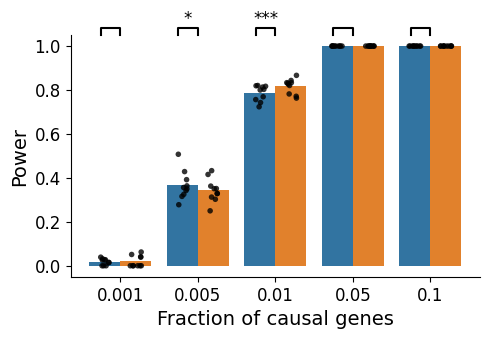

In [115]:
vlabel = 'sf'
overall_perf(
    res_df, vlabel,
    "../paper/main/causal_sf.pdf",
    xlabel="Fraction of causal genes",
    ylabel='Power'
)

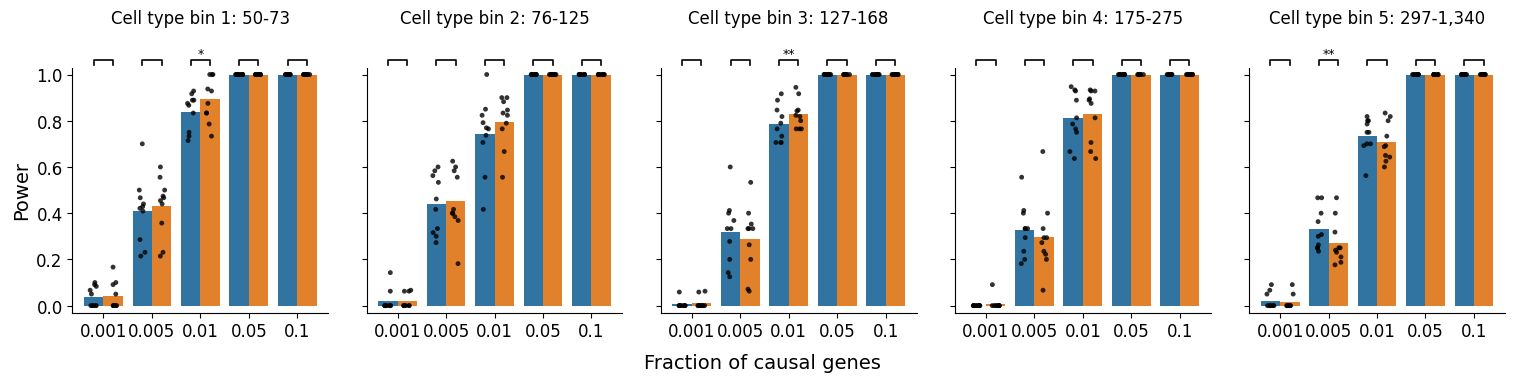

In [116]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sf_ctsize.pdf",
    xlabel="Fraction of causal genes",
    ylabel='Power'
)

# experiment B: vary noise_sd

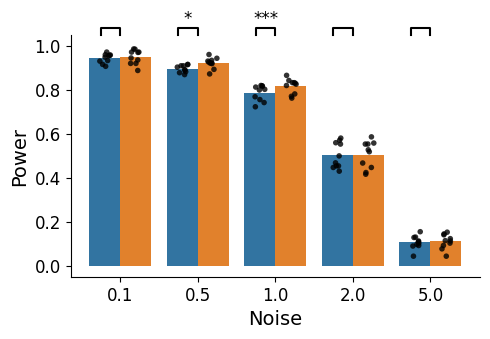

In [117]:
vlabel = 'ns'
overall_perf(
    res_df, vlabel, "../paper/main/causal_ns.pdf",
    xlabel="Noise",
    ylabel='Power',
)

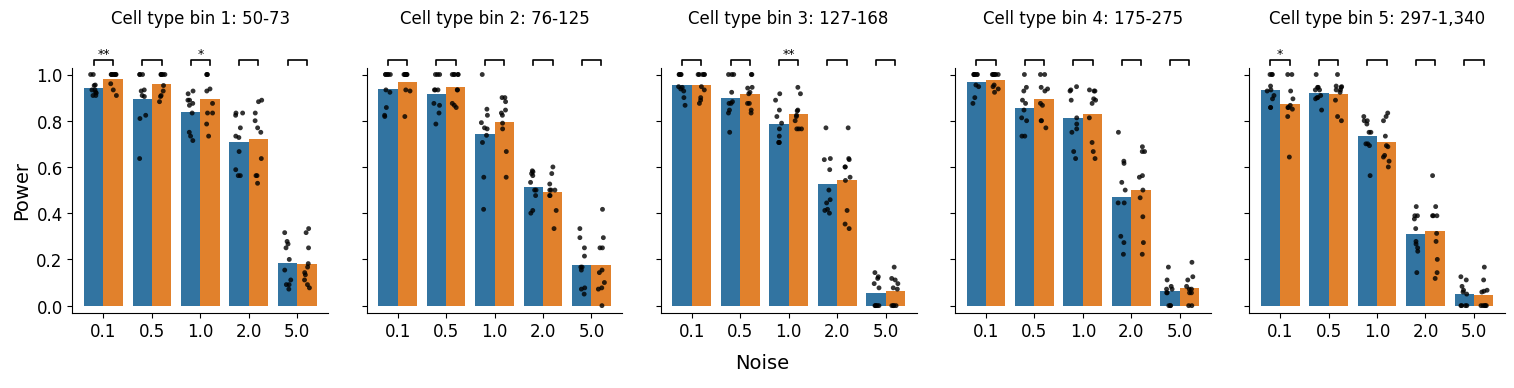

In [118]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_ns_ctsize.pdf",
    xlabel="Noise",
    ylabel='Power'
)

# experiment C: vary signal scaling factor

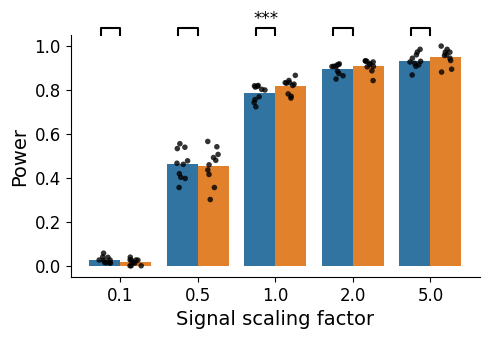

In [119]:
vlabel = 'b'
overall_perf(
    res_df, vlabel, "../paper/main/causal_factor.pdf",
    xlabel="Signal scaling factor",
    ylabel='Power',
)

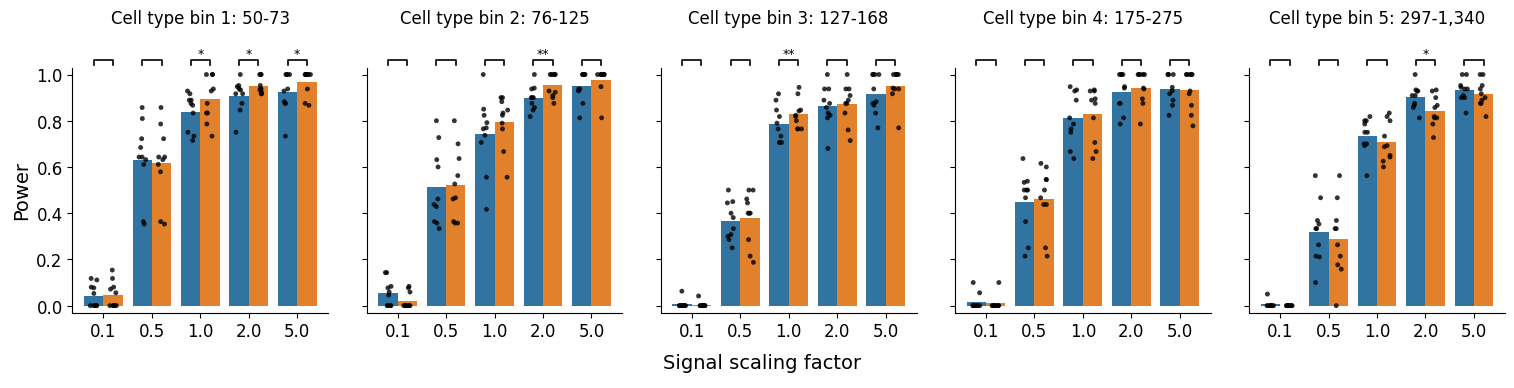

In [120]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_factor_ctsize.pdf",
    xlabel="Signal scaling factor",
    ylabel='Power'
)

# experiment D: vary sample rate

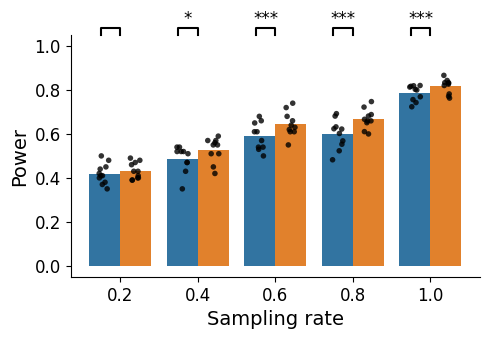

In [121]:
vlabel = 'sr'
overall_perf(
    res_df, vlabel, "../paper/main/causal_sr.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
)

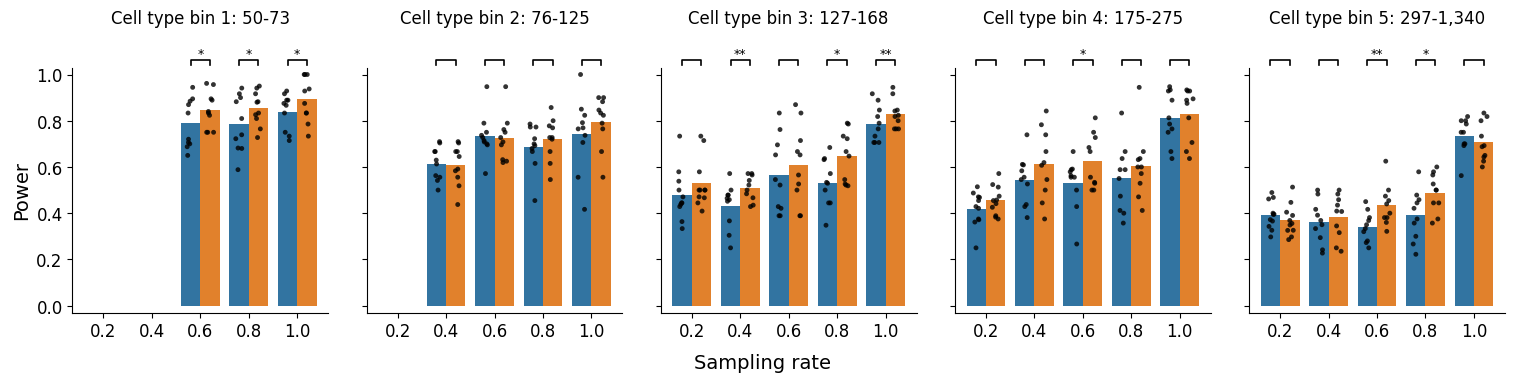

In [122]:
split_by_ct_perf(
    res_df, vlabel,
    "../paper/supp/causal_sr_ctsize.pdf",
    xlabel="Sampling rate",
    ylabel='Power',
    xticks_order=[0.2, 0.4, 0.6, 0.8, 1.0]
)

## try different ways to sampling subset

Active cells (within B cell): 171 / 570

Top genes (active vs rest):
      logFC_active_vs_rest  logFC_inactive_vs_rest  state_effect  abs_active  \
gene                                                                           
1236              2.011360                1.005298      1.006062    2.011360   
973               1.914932                1.943952     -0.029020    1.914932   
3117              1.827327                1.779429      0.047898    1.827327   
3109              1.813726                1.625705      0.188021    1.813726   
972               1.801572                1.828436     -0.026863    1.801572   
9214              1.720220                1.593133      0.127086    1.720220   
974               1.601173                1.771162     -0.169989    1.601173   
931               1.528043                1.644477     -0.116434    1.528043   
930               1.460304                1.467275     -0.006971    1.460304   
3112              1.455897                1.201371 

/Users/haoyuan/anaconda3/envs/icepop_mac/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


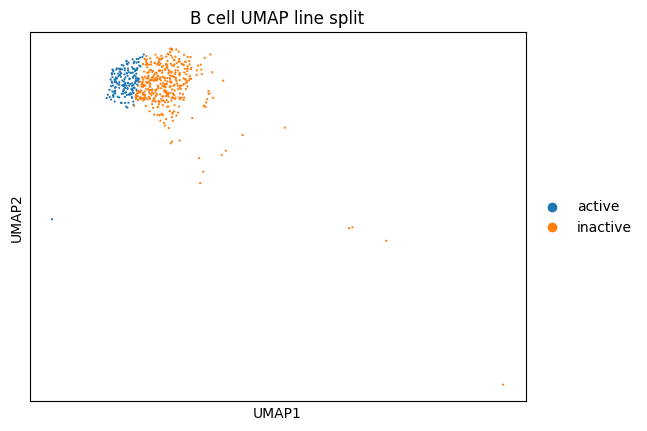

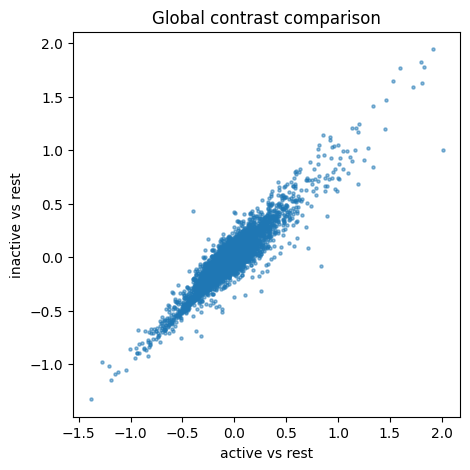

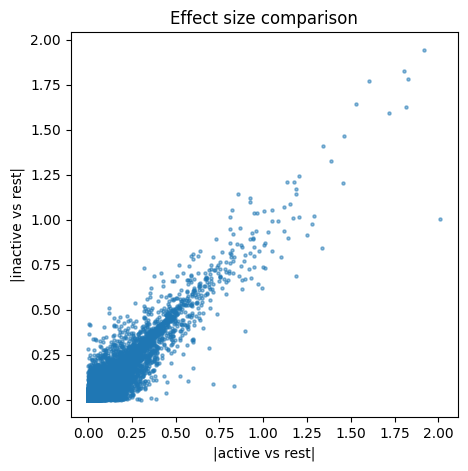

In [125]:
# -----------------------------
# SETTINGS
# -----------------------------
ct = "B cell"
frac_active = 0.3
seed = 10
n_top = 10

rng = np.random.default_rng(seed)

# -----------------------------
# LOAD DATA
# -----------------------------
adata = sc.read('../data/simulation/mc-75/TM_subset__score_calc.h5ad')

# -----------------------------
# SUBSET TARGET CELL TYPE
# -----------------------------
sub = adata[adata.obs["cell_type"] == ct].copy()

# ensure UMAP exists
if "X_umap" not in sub.obsm:
    sc.pp.pca(sub)
    sc.pp.neighbors(sub)
    sc.tl.umap(sub)

umap = sub.obsm["X_umap"]
x, y = umap[:, 0], umap[:, 1]

# -----------------------------
# LINE-BASED SPLIT
# -----------------------------
theta = rng.uniform(0, np.pi)
a, b = np.cos(theta), np.sin(theta)

proj = a * x + b * y
thresh = np.quantile(proj, 1 - frac_active)

mask = proj >= thresh
sub.obs["group"] = np.where(mask, "active", "inactive")

print(f"Active cells (within {ct}): {mask.sum()} / {len(mask)}")

# -----------------------------
# PROPAGATE TO FULL DATA
# -----------------------------
adata.obs["state"] = "other"
adata.obs.loc[sub.obs_names, "state"] = sub.obs["group"]

active_mask   = adata.obs["state"] == "active"
inactive_mask = adata.obs["state"] == "inactive"

# -----------------------------
# LOGFC FUNCTION
# -----------------------------
def compute_score_serial(X, idx):
    Xg = X[idx]
    Xr = X[~idx]

    mean_g = Xg.mean(axis=0).A1 if hasattr(Xg, "A1") else np.asarray(Xg.mean(axis=0)).ravel()
    mean_r = Xr.mean(axis=0).A1 if hasattr(Xr, "A1") else np.asarray(Xr.mean(axis=0)).ravel()

    logfc = np.log2((mean_g + 1) / (mean_r + 1))  # more stable than 1e-9
    return logfc

# -----------------------------
# COMPUTE LOGFC (GLOBAL REST)
# -----------------------------
X = adata.X

logfc_active   = compute_score_serial(X, active_mask)
logfc_inactive = compute_score_serial(X, inactive_mask)

# -----------------------------
# BUILD RESULT TABLE
# -----------------------------
df_fc = pd.DataFrame({
    "gene": adata.var_names,
    "logFC_active_vs_rest": logfc_active,
    "logFC_inactive_vs_rest": logfc_inactive
}).set_index("gene")

# difference between the two
df_fc["state_effect"] = (
    df_fc["logFC_active_vs_rest"] -
    df_fc["logFC_inactive_vs_rest"]
)

# magnitude comparison
df_fc["abs_active"] = np.abs(df_fc["logFC_active_vs_rest"])
df_fc["abs_inactive"] = np.abs(df_fc["logFC_inactive_vs_rest"])

# -----------------------------
# PRINT TOP GENES
# -----------------------------
top_active = df_fc.sort_values("logFC_active_vs_rest", ascending=False).head(n_top)
top_inactive = df_fc.sort_values("logFC_inactive_vs_rest", ascending=False).head(n_top)
top_state = df_fc.reindex(df_fc["state_effect"].abs().sort_values(ascending=False).index).head(n_top)

print("\nTop genes (active vs rest):")
print(top_active)

print("\nTop genes (inactive vs rest):")
print(top_inactive)

print("\nTop genes (state effect difference):")
print(top_state)

# -----------------------------
# VISUALIZATION
# -----------------------------

# 1. UMAP split
sc.pl.umap(sub, color="group", s=10, title=f"{ct} UMAP line split")

# 2. Symmetry / contrast plot
plt.figure(figsize=(5,5))
plt.scatter(
    df_fc["logFC_active_vs_rest"],
    df_fc["logFC_inactive_vs_rest"],
    s=5, alpha=0.5
)
plt.xlabel("active vs rest")
plt.ylabel("inactive vs rest")
plt.title("Global contrast comparison")
plt.show()

# 3. Magnitude comparison
plt.figure(figsize=(5,5))
plt.scatter(
    df_fc["abs_active"],
    df_fc["abs_inactive"],
    s=5, alpha=0.5
)
plt.xlabel("|active vs rest|")
plt.ylabel("|inactive vs rest|")
plt.title("Effect size comparison")
plt.show()

In [129]:

# ------------------------------------------
# simulate gwas signal from spec score
# ------------------------------------------
def choose_causal_genes(spec, signal_frac=0.2, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    G = len(spec)
    spec = np.asarray(spec)

    # --- choose signal genes (π1 = signal_frac) ---
    n_signal = int(np.floor(signal_frac * G))
    if n_signal < 1:
        raise ValueError("signal_frac too small, no signal genes selected.")

    weights = np.log1p(np.exp(spec))
    # weights = np.where(spec <= 0, 0, spec)
    weights = weights / weights.sum()

    signal_idx = rng.choice(G, size=n_signal, replace=False, p=weights)

    is_causal = np.zeros(G, dtype=bool)
    is_causal[signal_idx] = True
    return is_causal


def simulate_latent_from_specificity(
    spec: np.ndarray,
    is_causal: np.ndarray,
    beta: float = 1.0,
    noise_sd: float = 1.0,
    rng: np.random.Generator | None = None,
):
    """
    spec: 1D array of specificity scores (higher = more cell-type specific)
    is_causal: boolean array for which genes are 'signal'
    beta: strength of coupling between specificity and latent score
    noise_sd: how noisy the mapping is (higher = weaker separation)
    """
    if rng is None:
        rng = np.random.default_rng()

    noise = rng.normal(loc=0.0, scale=noise_sd, size=len(spec))

    y = np.zeros(len(spec))
    # causal genes: spec + noise
    y[is_causal] = beta * spec[is_causal] + noise[is_causal]
    # noncausal genes: pure noise
    y[~is_causal] = noise[~is_causal]

    return y


def assign_z_from_latent(y: np.ndarray, z_pool: np.ndarray) -> np.ndarray:
    """
    Rank-match GWAS-like z-scores to latent 'importance' scores.

    - Sort y ascending
    - Sort z_pool ascending
    - Assign largest z to largest y, etc.
    """
    assert y.shape[0] == z_pool.shape[0]
    # get ranks of y (0 .. G-1), ties broken arbitrarily
    y_rank = np.argsort(np.argsort(y))

    z_sorted = np.sort(z_pool)  # real z distribution
    z_sim = z_sorted[y_rank]  # map by rank

    return z_sim


def simulate_gwas_from_specificity_celltype(
    spec: pd.DataFrame,
    z_pool: pd.DataFrame,
    signal_frac: float = 0.1,
    beta: float = 1.0,
    noise_sd: float = 1.0,
    rng: np.random.Generator | None = None,
):
    """
    Simulate GWAS-like z-scores that:
      - follow the real z_pool distribution
      - are positively coupled to specificity for a subset of genes
    """
    if rng is None:
        rng = np.random.default_rng()

    # --- align indices ---
    genes = z_pool.index.intersection(spec.index)
    z_pool = z_pool.loc[genes].copy()
    spec = spec.loc[genes].copy()
    G = np.asarray(genes)

    # pick causal genes at cell type level (major trend of specificity of a cell type)
    is_causal = choose_causal_genes(spec, signal_frac=signal_frac, rng=rng)

    # turn to np array
    spec = np.asarray(spec)
    z_pool = np.asarray(z_pool.iloc[:, 0])

    # perturb score
    y = simulate_latent_from_specificity(
        spec,
        is_causal=is_causal,
        beta=beta,
        noise_sd=noise_sd,
        rng=rng,
    )

    z_sim = assign_z_from_latent(y, z_pool)

    return z_sim, G, is_causal